In [2]:
from google.colab import files
uploaded=files.upload()

Saving uber.csv to uber.csv


# Import the libraries needed for the project.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset and check the first 2 entries in the data.

In [4]:
df=pd.read_csv('uber.csv')
df.head(2)

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1


# Drop the Unnamed column and the key,as they are not needed in this project,They might create confusion as well

In [5]:
df.drop(columns=['Unnamed: 0','key'],inplace=True)

In [6]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


# Check the dataset as well,their datatypes

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   fare_amount        200000 non-null  float64
 1   pickup_datetime    200000 non-null  object 
 2   pickup_longitude   200000 non-null  float64
 3   pickup_latitude    200000 non-null  float64
 4   dropoff_longitude  199999 non-null  float64
 5   dropoff_latitude   199999 non-null  float64
 6   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 10.7+ MB


# Describe is ued to find the mathematical computations and the min and max from the data

In [8]:
df.describe()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


# **Check wheather the data contains a null value or not.**

In [9]:
df.isnull().sum()

,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,1
dropoff_latitude,1
passenger_count,0


# **Check the duplicated as well**

In [10]:
df.duplicated().sum()

np.int64(0)

**Now we have null values in the columns droppoff_longitude and dropoff_lattitude,Though the null value is 1,1 in both the columns,we decided to add a median in that place,we could have dropped it as well,but we found the median a much safer option.**

In [11]:
median_dropoff=df['dropoff_latitude'].median()
df['dropoff_latitude'].fillna(median_dropoff,inplace=True)

/tmp/ipykernel_5804/4068113797.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dropoff_latitude'].fillna(median_dropoff,inplace=True)


In [12]:
median_dropoff_longitude=df['dropoff_longitude'].median()
df['dropoff_longitude'].fillna(median_dropoff_longitude,inplace=True)

/tmp/ipykernel_5804/3766204860.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dropoff_longitude'].fillna(median_dropoff_longitude,inplace=True)


In [13]:
df.isnull().sum()

,0
fare_amount,0
pickup_datetime,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
passenger_count,0


# **Haversine Formula**

it is used to convert lattitude and longitude in to distance in km.

In [14]:
# from IPython.core.interactiveshell import dis
import numpy as np
def calculate(df):
  R=6371.0

  lat1=np.radians(df['pickup_latitude'])
  lon1=np.radians(df['pickup_longitude'])
  lat2=np.radians(df['dropoff_latitude'])
  lon2=np.radians(df['dropoff_longitude'])

  dlat=lat2-lat1
  dlon=lon2-lon1
  a=np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
  c=2*np.arctan2(np.sqrt(a),np.sqrt(1-a))
  distance=R*c
  return distance


df['distance_km']=calculate(df)


# **Creating columns from pickup_datetime column for the model to understand it**

In [15]:
df['pickup_datetime']=pd.to_datetime(df['pickup_datetime'])

df['hour']=df['pickup_datetime'].dt.hour
df['day_of_week']=df['pickup_datetime'].dt.day
df['month']=df['pickup_datetime'].dt.month


In [16]:
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour,day_of_week,month
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,19,7,5
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,20,17,7
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,21,24,8
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,8,26,6
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,17,28,8


In [17]:
df[['distance_km','hour','day_of_week','month']].head()

,distance_km,hour,day_of_week,month
0,1.683323,19,7,5
1,2.457590,20,17,7
2,5.036377,21,24,8
3,1.661683,8,26,6
4,4.475450,17,28,8


# **Exploratory Data Analysis**

In [18]:
df=df[df['fare_amount']>0]

In [19]:
df.head(2)

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,distance_km,hour,day_of_week,month
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,19,7,5
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,20,17,7


# **Remove the negative values(rows)**

In [20]:

df = df[(df['distance_km'] > 0.05) & (df['distance_km'] < 100)]


# **Keep the count from 1 to 6 for the passengers,as no overloading should be there.**

In [21]:
df=df[(df['passenger_count']>=1)&(df['passenger_count']<=6)]

In [22]:
df.shape[0]

192322

# **We need to know the relation between the fare and distance**
We would be using scatter plot over here

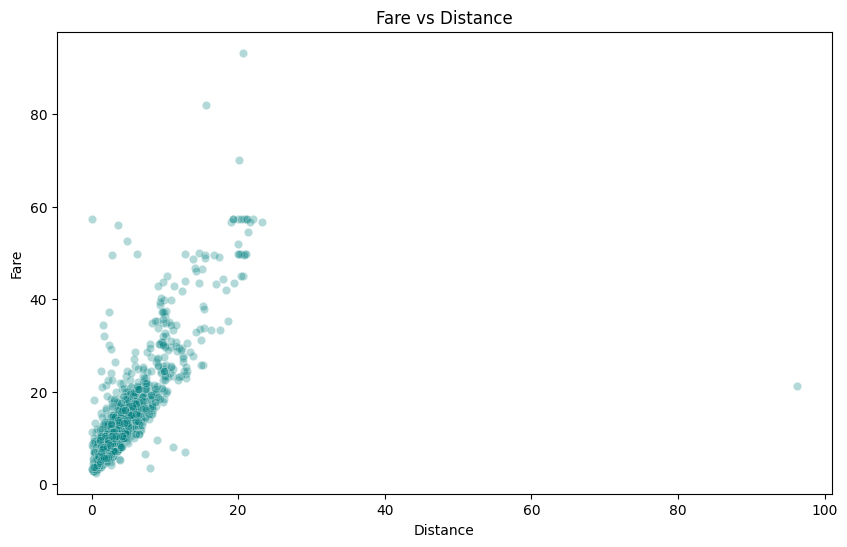

In [23]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df.sample(2000),x='distance_km',y='fare_amount',alpha=0.3,color='teal')
plt.title('Fare vs Distance')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.show()


# Here in the scatter plot we can see that as the distance increases the fare price also increases.Here at the distance of 20km we can see horizontal lines,these lines show the fixed price ,which is actually at the Manhattan to JFK Airport.Their is also an outlier at the 165 dollars,it is the ride to the airport.

# Here we want to know if the people take rides in the office peak hours.
So here we plot a lineplot, we calculate an average fare for every hour.

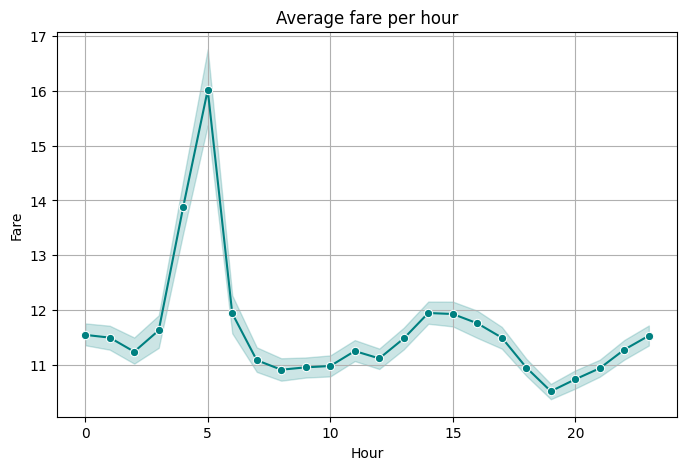

In [24]:
plt.figure(figsize=(8,5))
sns.lineplot(data=df,x='hour',y='fare_amount',marker='o',color='teal')
plt.title('Average fare per hour')
plt.xlabel('Hour')
plt.ylabel('Fare')
plt.grid(True)
plt.show()

#  **Here this green leaf-type thing is called Error band,which is used to know the variance.Here it shows how much we could trust the average.**

# **Linear Regression**
first we import the libraries.

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler



# We keep the numerical features in the X which are the features for the model and in y we keep the target ,which is 'fare_amount' for the project

In [26]:
X=df[['passenger_count','hour','day_of_week','month','passenger_count']]
y=df['fare_amount']


# Model Training and testing

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

# Scaling the data-Balancing it

In [28]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)


# Here the model training of the scaled data on the LinearRegression() model

In [29]:
model=LinearRegression()
model.fit(X_train_scaled,y_train)


LinearRegression()

In [30]:
# predictions from the model
y_pred=model.predict(X_test_scaled)

mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 90.5370801307966
R-squared: 0.0010495322225815285


# **Check the model coefficients,to see the weight of the features**

In [31]:
features = ['passenger_count', 'hour', 'day_of_week', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']
coefficients = model.coef_
# model.coef_-> used to find the weight of the features.

In [32]:
coefficients

array([ 0.0797442 , -0.17996949, -0.0140723 ,  0.22038541,  0.0797442 ])

# **Residuals**

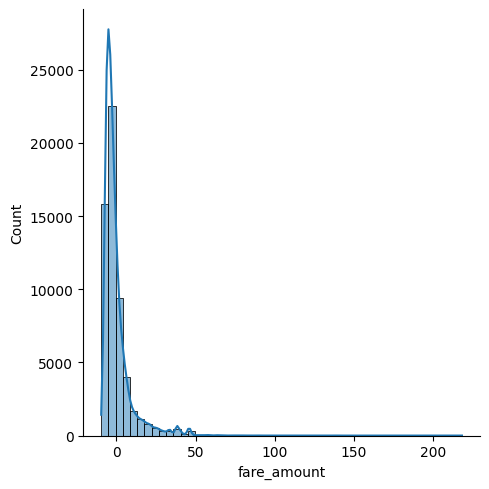

In [34]:
sns.displot(y_test-y_pred,bins=50,kde=True)
